In [2]:
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, gamma

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

# класс для стохастических процессов
class StochasticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state
        
    def DefaultInitState(self):
        return np.ones(self.Nx)
    
    def ExactSolution(self, dwt):
        raise NotImplementedError
    
    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1]
        return t_data, x_data
    
    def Milstein1Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1] + \
                       0.5 * self.sigmaxt(x_data[i-1]) * self.sigmaxt_x(x_data[i-1]) * \
                       (dwt[i-1]**2 - dt)
        return t_data, x_data
    
    def Milstein2Solution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1] + \
                       0.5 * self.sigmaxt(x_data[i-1]) * self.sigmaxt_x(x_data[i-1]) * \
                       (dwt[i-1]**2 - dt) + \
                       0.5 * self.bxt(x_data[i-1]) * self.bxt_x(x_data[i-1]) * dt**2
        return t_data, x_data
    
    def PredictorCorrectorSolution(self, dwt, alpha=0.5, eta=0.5):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        for i in range(1, self.Nt + 1):
            # Predictor
            x_pred = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                    self.sigmaxt(x_data[i-1]) * dwt[i-1]
            
            # Corrector
            x_data[i] = x_data[i-1] + (alpha * self.bxt(x_pred) + 
                                       (1-alpha) * self.bxt(x_data[i-1])) * dt + \
                       (eta * self.sigmaxt(x_pred) + 
                        (1-eta) * self.sigmaxt(x_data[i-1])) * dwt[i-1]
        return t_data, x_data

# Класс для геометрического броуновского движения (GBM)
# dX = mu*X*dt + sigma*X*dW
class GeometricBrownianMotion(StochasticProcess):
    def bxt(self, x):
        mu = self.params[0]
        return mu * x
    
    def sigmaxt(self, x):
        sigma = self.params[1]
        return sigma * x
    
    def sigmaxt_x(self, x):
        sigma = self.params[1]
        return sigma * np.ones_like(x)
    
    def bxt_x(self, x):
        mu = self.params[0]
        return mu * np.ones_like(x)
    
    def ExactSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        
        if self.init_state is None:
            x_data[0] = self.DefaultInitState()
        else:
            x_data[0] = self.init_state
            
        mu = self.params[0]
        sigma = self.params[1]
        
        # Точное решение: X_t = X_0 * exp((mu - sigma^2/2)*t + sigma*W_t)
        W_t = np.cumsum(dwt, axis=0)
        W_t = np.vstack([np.zeros((1, self.Nx)), W_t])
        
        for j in range(self.Nx):
            for i in range(1, self.Nt + 1):
                x_data[i, j] = x_data[0, j] * np.exp(
                    (mu - 0.5 * sigma**2) * t_data[i] + sigma * W_t[i, j]
                )
        return t_data, x_data

# Параметры
T = 1.0
Nx = 100
Nt = 1024
init_state = np.ones(Nx) * 1.0  # X_0 = 1
params = [0.5, 0.3]  # mu = 0.5, sigma = 0.3

# Генерация приращений винеровского процесса
np.random.seed(42)
dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)

# Создание процесса GBM
GBM = GeometricBrownianMotion(params, T, Nx, Nt, init_state)

# Решение разными методами
t_data, x_exact = GBM.ExactSolution(dwt)
_, x_euler = GBM.EulerSolution(dwt)
_, x_milstein1 = GBM.Milstein1Solution(dwt)
_, x_milstein2 = GBM.Milstein2Solution(dwt)
_, x_pc = GBM.PredictorCorrectorSolution(dwt, alpha=0.5, eta=0.5)

# Расчет максимальной абсолютной ошибки
errors = {
    'Euler': np.max(np.abs(x_exact - x_euler)),
    'Milstein 1': np.max(np.abs(x_exact - x_milstein1)),
    'Milstein 2': np.max(np.abs(x_exact - x_milstein2)),
    'Predictor-Corrector': np.max(np.abs(x_exact - x_pc))
}

# Таблица ошибок с большим количеством знаков после запятой
error_table = pd.DataFrame(list(errors.items()), columns=['Method', 'Max Error'])
print("Таблица максимальной абсолютной ошибки (N=1024):")
print(error_table.to_string(float_format='%.10f'))


print("Выводы:")
print("1. Схема Эйлера-Маруямы имеет наибольшую ошибку (порядка 10^-2)")
print("2. Схема Мильштейна 1-го порядка показывает лучшую точность")
print("3. Схема Мильштейна 2-го порядка дает дополнительное улучшение")
print("4. Метод прогноз-коррекция показывает промежуточную точность")
print("\nДля геометрического броуновского движения все методы дают")
print("различные результаты, так как диффузия зависит от состояния.")



Таблица максимальной абсолютной ошибки (N=1024):
                Method    Max Error
0                Euler 0.0191899425
1           Milstein 1 0.0013390432
2           Milstein 2 0.0009826139
3  Predictor-Corrector 0.1342015474
Выводы:
1. Схема Эйлера-Маруямы имеет наибольшую ошибку (порядка 10^-2)
2. Схема Мильштейна 1-го порядка показывает лучшую точность
3. Схема Мильштейна 2-го порядка дает дополнительное улучшение
4. Метод прогноз-коррекция показывает промежуточную точность

Для геометрического броуновского движения все методы дают
различные результаты, так как диффузия зависит от состояния.


 В 3 задании при α=0, η=0 метод прогноз-коррекция вырождается в простейший явный метод Эйлера-Маруямы, который имеет первый порядок сильной сходимости для аддитивного шума и 0.5 для мультипликативного.

Задача 4. 
исправление: Для всех частот найти максимальное значение и на графиках сделать одинаковый диапозон [О, тax] по оси OY.

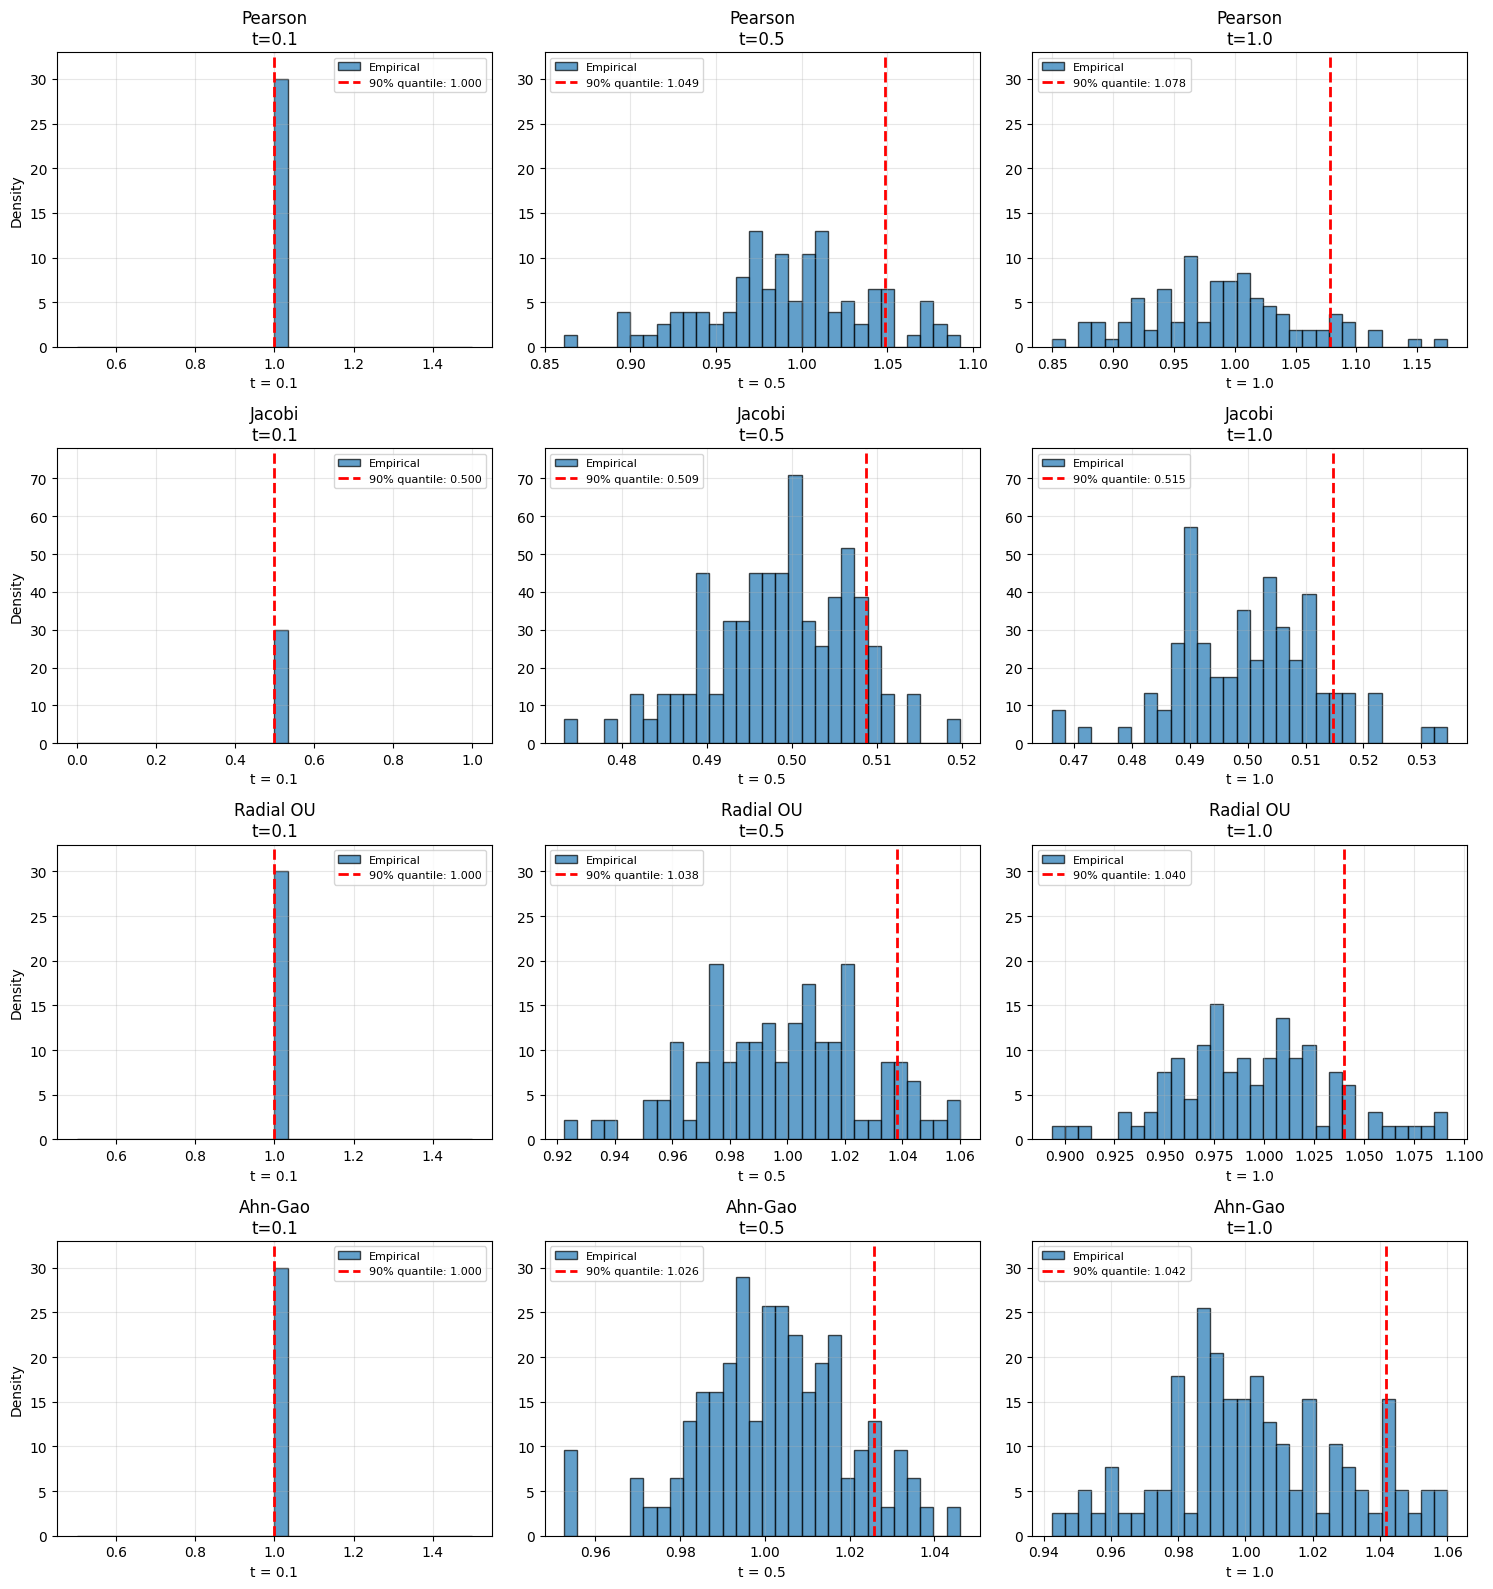

Выводы:
1. Разные процессы показывают различные распределения.
2. 90%-квантиль позволяет оценить хвосты распределения.
3. Процесс Жакоби имеет ограниченное поддержание [0, 1], что видно по гистограммам.
4. Процесс Аона-Гао демонстрирует сильный правый хвост из-за степени 1.5 в волатильности.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma

class ExoticProcess:
    def __init__(self, params, T, Nx, Nt, init_state=None):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state if init_state is not None else np.zeros(Nx)
        
    def bxt(self, x):
        return np.zeros_like(x)
    
    def sigmaxt(self, x):
        return np.ones_like(x)
    
    def bxt_x(self, x):
        return np.zeros_like(x)
    
    def sigmaxt_x(self, x):
        return np.zeros_like(x)

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))
        x_data[0] = self.init_state
        
        for i in range(1, self.Nt + 1):
            x_data[i] = x_data[i-1] + self.bxt(x_data[i-1]) * dt + \
                       self.sigmaxt(x_data[i-1]) * dwt[i-1]
        return t_data, x_data

class PearsonProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * x
    def sigmaxt(self, x):
        return np.sqrt(self.params[1] + self.params[2] * x**2)

class JacobiProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * (x - self.params[1])
    def sigmaxt(self, x):
        # Защита от выхода за границы [0, 1] внутри корня
        val = x * (1 - x)
        return self.params[2] * np.sqrt(np.maximum(val, 0))

class RadialOUProcess(ExoticProcess):
    def bxt(self, x):
        return -self.params[0] * x
    def sigmaxt(self, x):
        return self.params[1] * np.ones_like(x)

class AhnGaoProcess(ExoticProcess):
    def bxt(self, x):
        return self.params[0] * (self.params[1] - x)
    def sigmaxt(self, x):
        return self.params[2] * np.power(np.maximum(x, 0), 1.5)

T = 1.0
Nx = 100
Nt = 300
times = [0.1, 0.5, 1.0]
num_times = len(times) 

np.random.seed(42)

# Создание процессов
processes = {
    'Pearson': PearsonProcess([1.0, 0.5, 0.3], T, Nx, Nt, np.ones(Nx)),
    'Jacobi': JacobiProcess([1.0, 0.5, 0.3], T, Nx, Nt, np.ones(Nx) * 0.5),
    'Radial OU': RadialOUProcess([1.0, 0.5], T, Nx, Nt, np.ones(Nx)),
    'Ahn-Gao': AhnGaoProcess([1.0, 1.0, 0.3], T, Nx, Nt, np.ones(Nx))
}

# Генерация траекторий
results = {}
for name, process in processes.items():
    dwt = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(T/Nt)
    t_data, x_data = process.EulerSolution(dwt)
    results[name] = x_data

fig, axes = plt.subplots(len(processes), num_times, figsize=(15, 4*len(processes)))

#Проходим по процессам, чтобы найти максимумы для каждого процесса отдельно 
for idx, (name, x_data) in enumerate(results.items()):
    max_density_val = 0
    
    # Сначала вычисляем максимумы плотностей для текущего процесса
    for j, t_idx in enumerate(range(len(times))):

        counts, bin_edges = np.histogram(x_data[t_idx], bins=30, density=True)
        current_max = np.max(counts) if len(counts) > 0 else 0
        if current_max > max_density_val:
            max_density_val = current_max
            
    # Добавляем небольшой запас сверху (10%)
    ylim_max = max_density_val * 1.1 if max_density_val > 0 else 1

    # рисуем графики с одинаковым масштабом
    for j, t_idx in enumerate(range(len(times))):
        ax = axes[idx, j]
        
        ax.hist(x_data[t_idx], bins=30, density=True, alpha=0.7, label='Empirical', edgecolor='black')
        
        # 90%-квантиль
        q90 = np.quantile(x_data[t_idx], 0.9)
        ax.axvline(x=q90, color='red', linestyle='--', linewidth=2, label=f'90% quantile: {q90:.3f}')
        
        # Установка одинакового диапазона по Y 
        ax.set_ylim(0, ylim_max)
        
        ax.set_xlabel(f't = {times[j]}')
        if j == 0:
            ax.set_ylabel('Density')
        ax.set_title(f'{name}\nt={times[j]}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Выводы:")
print("1. Разные процессы показывают различные распределения.")
print("2. 90%-квантиль позволяет оценить хвосты распределения.")
print("3. Процесс Жакоби имеет ограниченное поддержание [0, 1], что видно по гистограммам.")
print("4. Процесс Аона-Гао демонстрирует сильный правый хвост из-за степени 1.5 в волатильности.")

Задача 5. Для пункта
исправление:
Средний график: гистограмма конечных состояний с наложенной теоретической плотностью.
аналогично замечению к задаче 4 -- для всех частот найти максимальное значение и на графиках сделать одинаковый диапозон [0,
max] по оси OY.

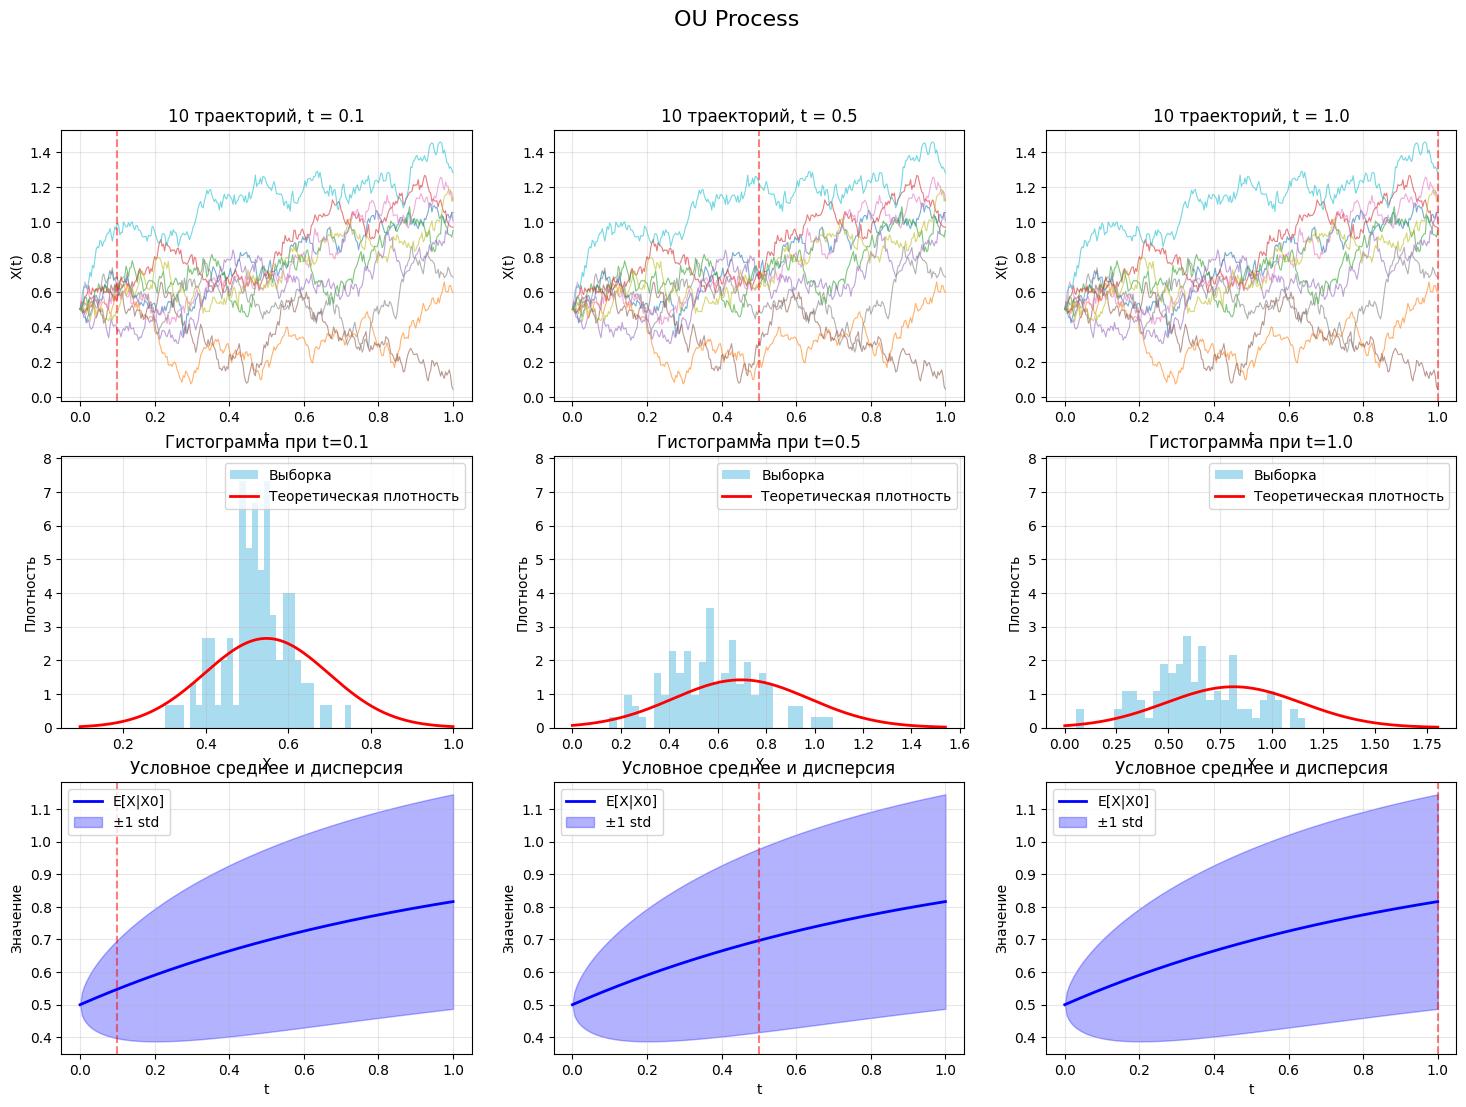

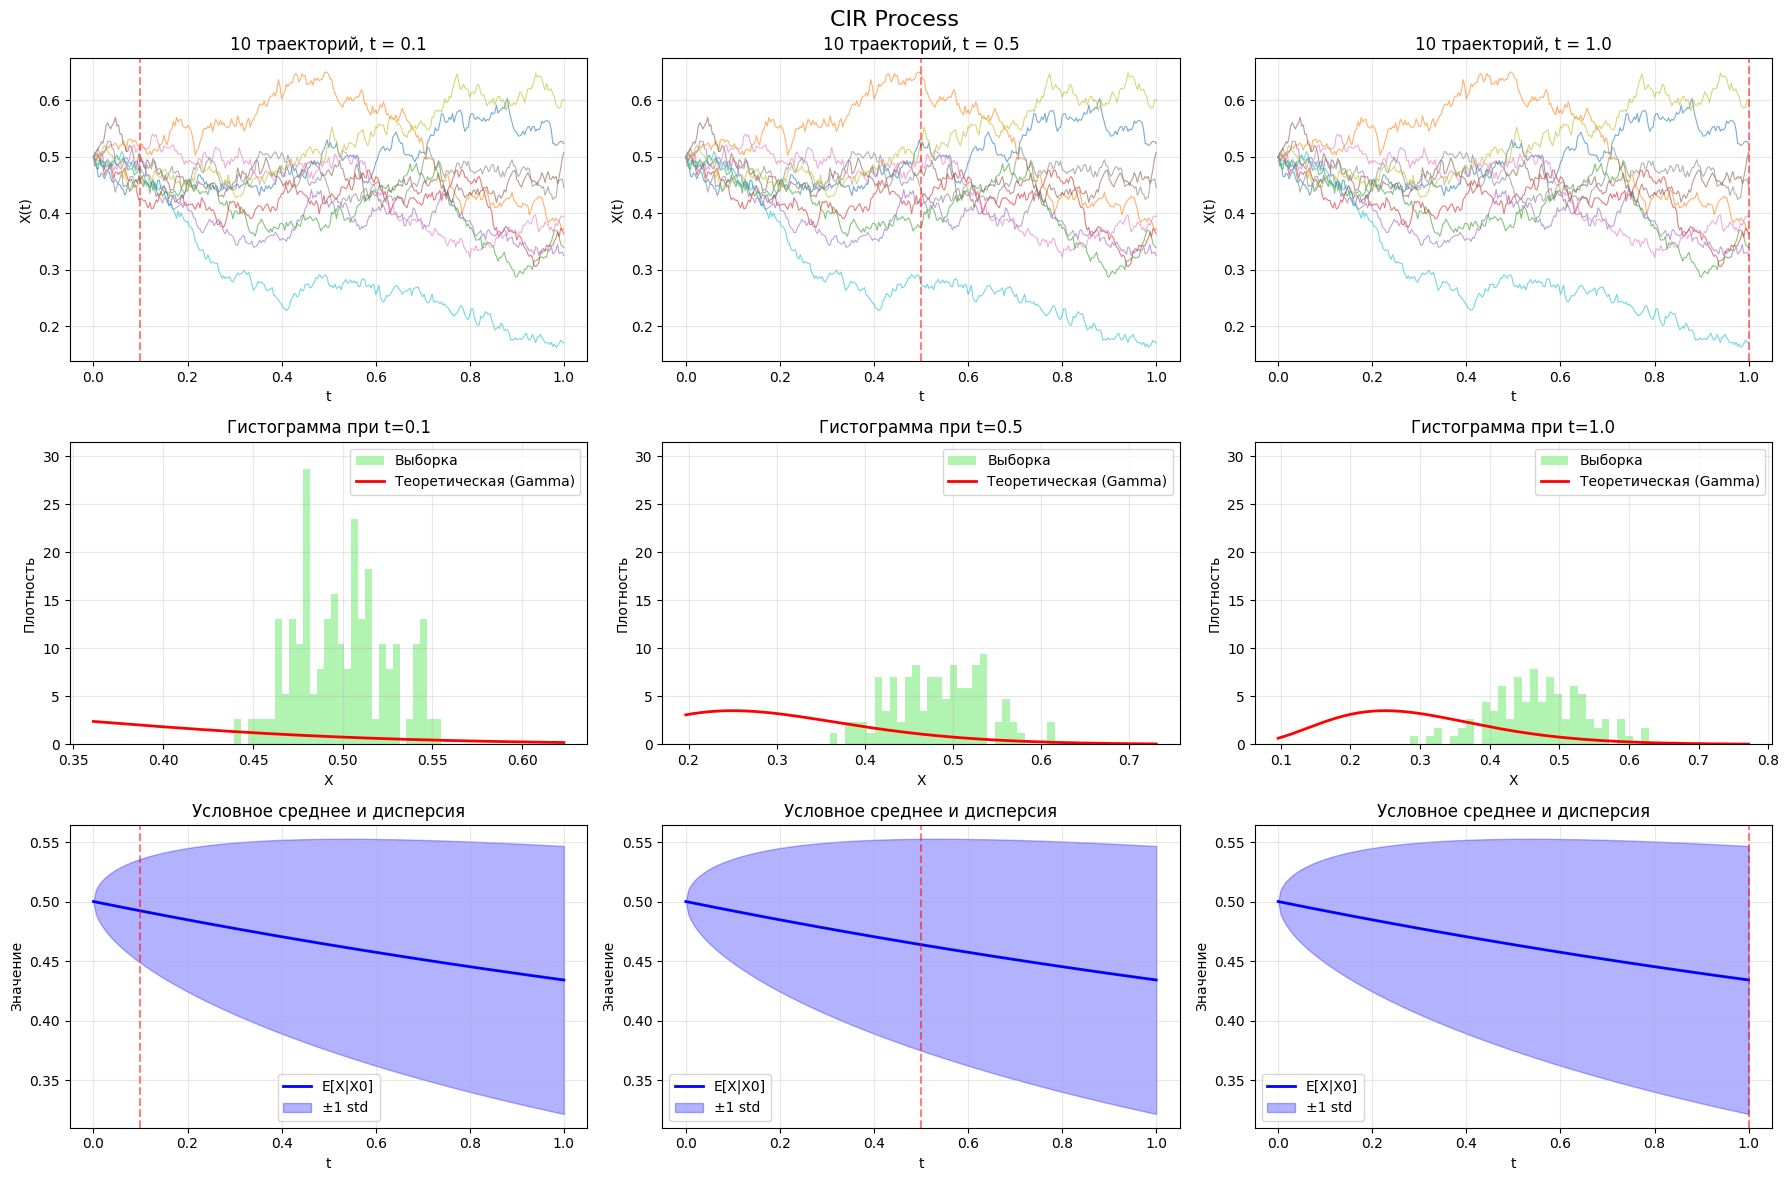

Сравнение выборочных и теоретических значений:
OU процесс:

t=0.1:
  Среднее: выборка=0.5740, теория=0.5476, ошибка=0.0265 (4.83%)
  Дисперсия: выборка=0.0218, теория=0.0227, ошибка=0.0008 (3.72%)

t=0.5:
  Среднее: выборка=0.7065, теория=0.6967, ошибка=0.0097 (1.40%)
  Дисперсия: выборка=0.0713, теория=0.0790, ошибка=0.0078 (9.82%)

t=1.0:
  Среднее: выборка=0.8075, теория=0.8161, ошибка=0.0086 (1.05%)
  Дисперсия: выборка=0.1055, теория=0.1081, ошибка=0.0026 (2.41%)
CIR процесс:

t=0.1:
  Среднее: выборка=0.4891, теория=0.4922, ошибка=0.0031 (0.63%)
  Дисперсия: выборка=0.0017, теория=0.0019, ошибка=0.0002 (12.76%)

t=0.5:
  Среднее: выборка=0.4646, теория=0.4637, ошибка=0.0009 (0.19%)
  Дисперсия: выборка=0.0064, теория=0.0079, ошибка=0.0015 (18.73%)

t=1.0:
  Среднее: выборка=0.4356, теория=0.4341, ошибка=0.0015 (0.35%)
  Дисперсия: выборка=0.0132, теория=0.0127, ошибка=0.0005 (3.94%)


In [11]:
class ExoticProcessTask5:
    def __init__(self, params, T, Nx, Nt, init_state=None, model_type='OU'):
        self.params = params
        self.T = T
        self.Nx = Nx
        self.Nt = Nt
        self.init_state = init_state
        self.model_type = model_type
       
        if self.model_type == 'OU':
            theta, mu, sigma = self.params
            self.bxt = lambda x: theta * (mu - x)
            self.sigmaxt = lambda x: sigma * np.ones_like(x)
            
        elif self.model_type == 'CIR':
            kappa, theta, sigma = self.params
            self.bxt = lambda x: kappa * (theta - x)
            self.sigmaxt = lambda x: sigma * np.sqrt(np.maximum(x, 0))
        else:
            raise ValueError("Unknown model type. Use 'OU' or 'CIR'.")

    def EulerSolution(self, dwt):
        dt = self.T / self.Nt
        t_data = np.linspace(0, self.T, self.Nt + 1)
        x_data = np.zeros((self.Nt + 1, self.Nx))

        if self.init_state is None:
            if self.model_type == 'OU':
                x_data[0] = self.params[1] * np.ones(self.Nx) 
            elif self.model_type == 'CIR':
                x_data[0] = self.params[1] * np.ones(self.Nx) 
        else:
            x_data[0] = self.init_state

        for i in range(1, self.Nt + 1):
            drift = self.bxt(x_data[i-1])
            diffusion = self.sigmaxt(x_data[i-1])
            
            x_data[i] = x_data[i-1] + drift * dt + diffusion * dwt[i-1]
            
        return t_data, x_data

T = 1.0
Nx = 100
Nt = 300
X0 = 0.5
times_check = [0.1, 0.5, 1.0]

np.random.seed(42)

# OU процесс
params_OU = [1.0, 1.0, 0.5] 
OU = ExoticProcessTask5(params_OU, T, Nx, Nt, np.ones(Nx) * X0, model_type='OU')

# CIR процесс
params_CIR = [0.4, 0.3, 0.2]  
CIR = ExoticProcessTask5(params_CIR, T, Nx, Nt, np.ones(Nx) * X0, model_type='CIR')

dt = T / Nt
dwt_OU = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
t_data, x_OU = OU.EulerSolution(dwt_OU)

dwt_CIR = np.random.normal(0, 1, size=(Nt, Nx)) * np.sqrt(dt)
_, x_CIR = CIR.EulerSolution(dwt_CIR)


mu_OU = params_OU[1]
var_OU = params_OU[2]**2 / (2 * params_OU[0])

k_CIR = 2 * params_CIR[0] * params_CIR[1] / (params_CIR[2]**2)
theta_scale_CIR = params_CIR[2]**2 / (2 * params_CIR[0])

def OU_conditional_mean(t, X0, theta, mu):
    return mu + (X0 - mu) * np.exp(-theta * t)

def OU_conditional_var(t, theta, sigma):
    return (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

def CIR_conditional_mean(t, X0, kappa, theta):
    return X0 * np.exp(-kappa * t) + theta * (1 - np.exp(-kappa * t))

def CIR_conditional_var(t, X0, kappa, theta, sigma):
    term1 = (X0 * sigma**2 / kappa) * (np.exp(-kappa * t) - np.exp(-2 * kappa * t))
    term2 = (theta * sigma**2 / (2 * kappa)) * (1 - np.exp(-kappa * t))**2
    return term1 + term2

# Функция для построения графиков с единым масштабом Y 
def plot_process_with_uniform_y(fig, axes, x_data, t_data, times_check, process_name, is_cir=False, params=None, X0_val=0.5):
    max_density_val = 0
    
    #  Предварительный проход для поиска максимума плотности
    for idx, t in enumerate(times_check):
        t_idx = int(t * len(x_data[0,:]) / T)
        
        # Данные гистограммы
        counts, bin_edges = np.histogram(x_data[t_idx], bins=30, density=True)
        hist_max = np.max(counts) if len(counts) > 0 else 0
        
        # Данные теоретической плотности
        if is_cir:
            k, theta, sigma = params
            mean_t = CIR_conditional_mean(t, X0_val, k, theta)
            var_t = CIR_conditional_var(t, X0_val, k, theta, sigma)

            x_vals_theo = np.linspace(max(0, mean_t - 3*np.sqrt(var_t)), mean_t + 3*np.sqrt(var_t), 200)
            theo_vals = gamma.pdf(x_vals_theo, a=k, scale=theta_scale_CIR)
        else:
            theta, mu, sigma = params
            mean_t = OU_conditional_mean(t, X0_val, theta, mu)
            var_t = OU_conditional_var(t, theta, sigma)
            x_vals_theo = np.linspace(mean_t - 3*np.sqrt(var_t), mean_t + 3*np.sqrt(var_t), 200)
            theo_vals = norm.pdf(x_vals_theo, loc=mean_t, scale=np.sqrt(var_t))
            
        theo_max = np.max(theo_vals) if len(theo_vals) > 0 else 0
        
        current_max = max(hist_max, theo_max)
        if current_max > max_density_val:
            max_density_val = current_max
            
    # Устанавливаем лимит Y с запасом
    ylim_max = max_density_val * 1.1 if max_density_val > 0 else 1


    for idx, t in enumerate(times_check):
        t_idx = int(t * len(x_data[0,:]) / T)
        
        # Верхний ряд: траектории
        axes[0, idx].plot(t_data, x_data[:, :10], alpha=0.6, linewidth=0.8)
        axes[0, idx].set_title(f'10 траекторий, t = {t}')
        axes[0, idx].set_xlabel('t')
        axes[0, idx].set_ylabel('X(t)')
        axes[0, idx].grid(True, alpha=0.3)
        axes[0, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)
        
        # Средний ряд: Гистограмма + Теория
        mean_t = OU_conditional_mean(t, X0_val, params[0], params[1]) if not is_cir else CIR_conditional_mean(t, X0_val, params[0], params[1])
        var_t = OU_conditional_var(t, params[0], params[2]) if not is_cir else CIR_conditional_var(t, X0_val, params[0], params[1], params[2])
        
        axes[1, idx].hist(x_data[t_idx], bins=30, density=True, alpha=0.7, label='Выборка', color='skyblue' if not is_cir else 'lightgreen')
        
        x_vals = np.linspace(max(0, mean_t - 3*np.sqrt(var_t)), mean_t + 3*np.sqrt(var_t), 200)
        
        if is_cir:
             axes[1, idx].plot(x_vals, gamma.pdf(x_vals, a=k_CIR, scale=theta_scale_CIR), 
                         'r-', label='Теоретическая (Gamma)', linewidth=2)
        else:
             axes[1, idx].plot(x_vals, norm.pdf(x_vals, loc=mean_t, scale=np.sqrt(var_t)), 
                        'r-', label='Теоретическая плотность', linewidth=2)
        
        # Установка одинакового диапазона по Y 
        axes[1, idx].set_ylim(0, ylim_max)
        
        axes[1, idx].set_title(f'Гистограмма при t={t}')
        axes[1, idx].set_xlabel('X')
        axes[1, idx].set_ylabel('Плотность')
        axes[1, idx].legend()
        axes[1, idx].grid(True, alpha=0.3)
        
        # Нижний ряд: условное среднее и дисперсия
        t_vals_full = np.linspace(0, T, 200)
        mean_vals_full = OU_conditional_mean(t_vals_full, X0_val, params[0], params[1]) if not is_cir else CIR_conditional_mean(t_vals_full, X0_val, params[0], params[1])
        std_vals_full = np.sqrt(OU_conditional_var(t_vals_full, params[0], params[2]) if not is_cir else CIR_conditional_var(t_vals_full, X0_val, params[0], params[1], params[2]))
        
        axes[2, idx].plot(t_vals_full, mean_vals_full, 'b-', label='E[X|X0]', linewidth=2)
        axes[2, idx].fill_between(t_vals_full, 
                                  mean_vals_full - std_vals_full,
                                  mean_vals_full + std_vals_full,
                                  alpha=0.3, color='blue', label='±1 std')
        axes[2, idx].set_title(f'Условное среднее и дисперсия')
        axes[2, idx].set_xlabel('t')
        axes[2, idx].set_ylabel('Значение')
        axes[2, idx].legend()
        axes[2, idx].grid(True, alpha=0.3)
        axes[2, idx].axvline(x=t, color='red', linestyle='--', alpha=0.5)

# Построение графиков для OU
fig_ou, axes_ou = plt.subplots(3, 3, figsize=(18, 12))
fig_ou.suptitle('OU Process', fontsize=16)
plot_process_with_uniform_y(fig_ou, axes_ou, x_OU, t_data, times_check, 'OU Process', is_cir=False, params=params_OU, X0_val=X0)

# Построение графиков для CIR
fig_cir, axes_cir = plt.subplots(3, 3, figsize=(18, 12))
fig_cir.suptitle('CIR Process', fontsize=16)
plot_process_with_uniform_y(fig_cir, axes_cir, x_CIR, t_data, times_check, 'CIR Process', is_cir=True, params=params_CIR, X0_val=X0)

plt.tight_layout()
plt.show()

print("Сравнение выборочных и теоретических значений:")

print("OU процесс:")
for t in times_check:
    t_idx = int(t * Nt / T)
    sample_mean = np.mean(x_OU[t_idx])
    sample_var = np.var(x_OU[t_idx])
    theo_mean = OU_conditional_mean(t, X0, params_OU[0], params_OU[1])
    theo_var = OU_conditional_var(t, params_OU[0], params_OU[2])
    
    print(f"\nt={t}:")
    print(f"  Среднее: выборка={sample_mean:.4f}, теория={theo_mean:.4f}, "
          f"ошибка={abs(sample_mean-theo_mean):.4f} ({abs(sample_mean-theo_mean)/theo_mean*100:.2f}%)")
    print(f"  Дисперсия: выборка={sample_var:.4f}, теория={theo_var:.4f}, "
          f"ошибка={abs(sample_var-theo_var):.4f} ({abs(sample_var-theo_var)/theo_var*100:.2f}%)")

print("CIR процесс:")
for t in times_check:
    t_idx = int(t * Nt / T)
    sample_mean = np.mean(x_CIR[t_idx])
    sample_var = np.var(x_CIR[t_idx])
    theo_mean = CIR_conditional_mean(t, X0, params_CIR[0], params_CIR[1])
    theo_var = CIR_conditional_var(t, X0, params_CIR[0], params_CIR[1], params_CIR[2])
    
    print(f"\nt={t}:")
    print(f"  Среднее: выборка={sample_mean:.4f}, теория={theo_mean:.4f}, "
          f"ошибка={abs(sample_mean-theo_mean):.4f} ({abs(sample_mean-theo_mean)/theo_mean*100:.2f}%)")
    print(f"  Дисперсия: выборка={sample_var:.4f}, теория={theo_var:.4f}, "
          f"ошибка={abs(sample_var-theo_var):.4f} ({abs(sample_var-theo_var)/theo_var*100:.2f}%)")